# Machine Learning Classification Project
## Credit Card Default Prediction
---

In [100]:
import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn ucimlrepo --break-system-packages

## 1. Problem Framing

**Problem:** Predict whether a credit card client will default on their payment next month based on their demographic and financial history.

**Dataset:** Default of Credit Card Clients (Taiwan) — 30,000 clients, 23 features.

**Source:** https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

**Target Variable:** `default.payment.next.month` (Binary: 1 = defaulted, 0 = did not default)

**Classification Type:** Binary Classification

**Expected Challenges:**
- Class imbalance (~78% non-default vs ~22% default)
- Large feature value ranges requiring scaling
- Undocumented categorical values in EDUCATION and MARRIAGE columns

## 2. Imports

In [101]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import seaborn as sns

## 3. Data Acquisition & Loading

Fetching the dataset directly from UCI ML Repository using its official ID (350).
We then separate features (X) and target (y) and inspect the metadata and variable descriptions.

In [102]:
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables)

{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

## 4. Data Cleaning & Preprocessing

### 4.1 Missing Values Check

Checking for any missing values across all features and the target variable.
A complete dataset requires no imputation, but this step must be documented.

In [103]:
print("Missing values in X:")
print(X.isnull().sum())
print(f"\nTotal missing values in X: {X.isnull().sum().sum()}")
print(f"\nMissing values in y: {y.isnull().sum().sum()}")

Missing values in X:
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
dtype: int64

Total missing values in X: 0

Missing values in y: 0


### 4.2 Data Consistency Checks

Checking for logically impossible values such as ages below 18 or above 100,
and credit limits that are zero or negative, which would indicate data entry errors.

In [104]:
##data consisty 
age_issue = X[(X['X5'] < 18) | (X['X5'] > 100)]
print(f"Number of age outliers: {len(age_issue)}")

limit_issue = X[(X['X1'] <=0) ]
print(f"Number of limit_BAL outliers: {len(limit_issue)}")

Number of age outliers: 0
Number of limit_BAL outliers: 0


### 4.3 Duplicate Check & Removal

Checking for duplicate IDs and duplicate rows. Duplicate rows are removed to prevent
the model from learning the same pattern multiple times, which could lead to overfitting.

In [105]:
##check duplicate ID
if 'ID' in X.columns:
    print(f"Duplicate IDs: {X.duplicated(subset=['ID']).sum()}")
else:
    print(f"Duplicate Indices: {X.index.duplicated().sum()}")

##check duplicate rows without index
print(f"Total duplicate rows: {X.duplicated().sum()}")

## delete duplicate rows
X = X.drop_duplicates()
y = y.loc[X.index]

# Make sure X and y have matching rows
y = y.loc[X.index]
# Verify they match
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Duplicate Indices: 0
Total duplicate rows: 56
X shape: (29944, 23)
y shape: (29944, 1)


In [106]:
# Reset index to avoid any alignment issues
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print(f"X shape after reset: {X.shape}")
print(f"y shape after reset: {y.shape}")

X shape after reset: (29944, 23)
y shape after reset: (29944, 1)


### 4.4 Handling Categorical Values

The EDUCATION (X3) column contains undocumented values (0, 5, 6) not described
in the dataset documentation. These are grouped into category 4 (Others).
Similarly, MARRIAGE (X4) contains undocumented value 0, grouped into category 3 (Others).

In [107]:
##Handling Categorical Values
print(X.nunique())
X['X3'] = X['X3'].replace([0, 5, 6], 4)
X['X4'] = X['X4'].replace([0], 3)
print(X.nunique())

X1        81
X2         2
X3         7
X4         4
X5        56
X6        11
X7        11
X8        11
X9        11
X10       10
X11       10
X12    22723
X13    22346
X14    22026
X15    21548
X16    21010
X17    20604
X18     7943
X19     7899
X20     7518
X21     6937
X22     6897
X23     6939
dtype: int64
X1        81
X2         2
X3         4
X4         3
X5        56
X6        11
X7        11
X8        11
X9        11
X10       10
X11       10
X12    22723
X13    22346
X14    22026
X15    21548
X16    21010
X17    20604
X18     7943
X19     7899
X20     7518
X21     6937
X22     6897
X23     6939
dtype: int64


### 4.5 One-Hot Encoding

SEX (X2), EDUCATION (X3), and MARRIAGE (X4) are nominal categorical variables
with no inherent ordering. One-hot encoding is applied to prevent the model from
incorrectly assuming any numerical relationship between their categories.

In [108]:
## one-hot coding 
X_final = pd.get_dummies(X, columns=['X2', 'X3', 'X4'], drop_first=True , dtype=int)
print(X_final.head())
print(X_final.columns)

       X1  X5  X6  X7  X8  X9  X10  X11    X12    X13    X14    X15    X16  \
0   20000  24   2   2  -1  -1   -2   -2   3913   3102    689      0      0   
1  120000  26  -1   2   0   0    0    2   2682   1725   2682   3272   3455   
2   90000  34   0   0   0   0    0    0  29239  14027  13559  14331  14948   
3   50000  37   0   0   0   0    0    0  46990  48233  49291  28314  28959   
4   50000  57  -1   0  -1   0    0    0   8617   5670  35835  20940  19146   

     X17   X18    X19    X20   X21   X22   X23  X2_2  X3_2  X3_3  X3_4  X4_2  \
0      0     0    689      0     0     0     0     1     1     0     0     0   
1   3261     0   1000   1000  1000     0  2000     1     1     0     0     1   
2  15549  1518   1500   1000  1000  1000  5000     1     1     0     0     1   
3  29547  2000   2019   1200  1100  1069  1000     1     1     0     0     0   
4  19131  2000  36681  10000  9000   689   679     0     1     0     0     0   

   X4_3  
0     0  
1     0  
2     0  
3     0  


### 4.6 Class Imbalance Check

Checking the distribution of the target variable to identify any class imbalance.
An imbalanced dataset can cause the model to be biased toward the majority class,
reducing its ability to correctly identify defaulters.

In [109]:
##Imbalance Check
print(y.value_counts(normalize=True)*100)

Y
0    77.885386
1    22.114614
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis (EDA)

### 5.1 Class Distribution

Visualizing the distribution of the target variable to understand the class balance
between defaulters and non-defaulters in the dataset.

Counts:
  Class 0: 23322 clients
  Class 1: 6622 clients

Percentages:
  Class 0: 77.89%
  Class 1: 22.11%


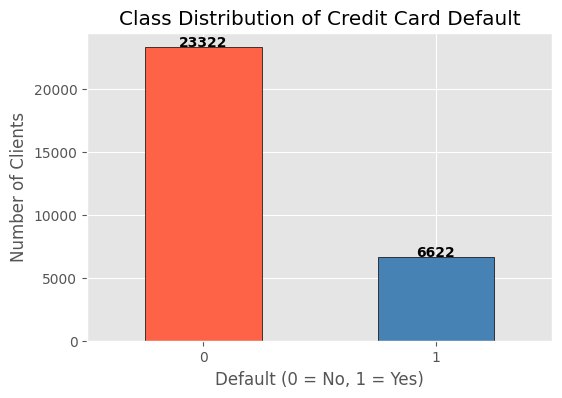

In [110]:
# Count values
counts = y['Y'].value_counts()
percentages = y['Y'].value_counts(normalize=True) * 100

print("Counts:")
for label, cnt in counts.items():
    print(f"  Class {label}: {cnt} clients")

print("\nPercentages:")
for label, pct in percentages.items():
    print(f"  Class {label}: {pct:.2f}%")

# Plot
plt.figure(figsize=(6,4))
counts.plot(kind='bar', color=['tomato','steelblue'], edgecolor='black')
plt.title('Class Distribution of Credit Card Default')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Number of Clients')
plt.xticks(rotation=0)

# Add numbers on top of bars to show actual counts
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.show()

### 5.2 Payment Status vs Default Rate

Visualizing the relationship between payment status over the Earliest 3 months (X9->June, X10->May, X11->April)
and the default rate.

 This helps understand whether late payments are a strong predictor of default.

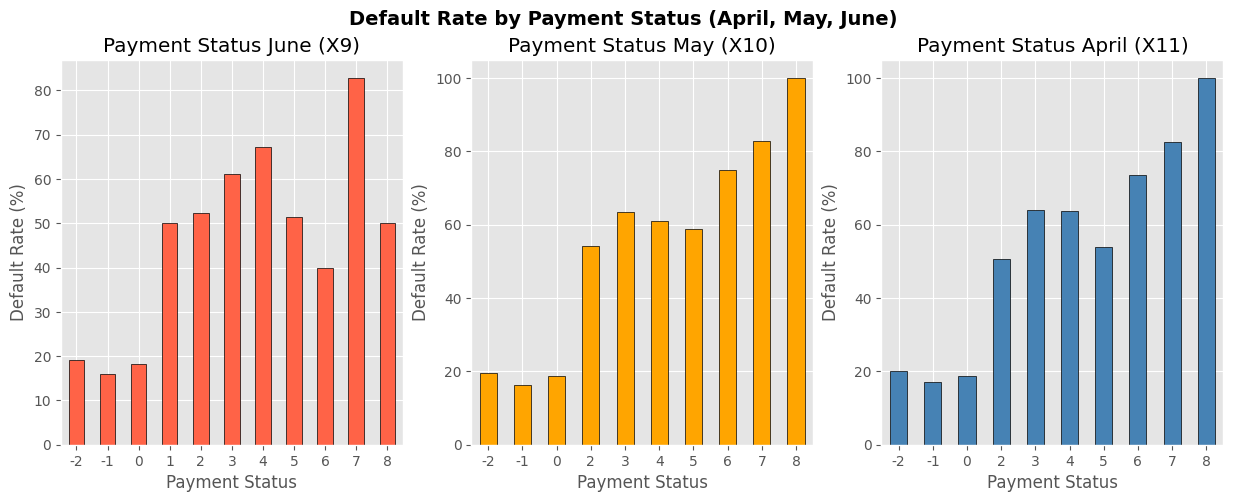

In [111]:
# Combine X and y temporarily for plotting
plot_df = X_final.copy()
plot_df['Y'] = y['Y'].values

# Calculate default rate for each payment status column with percentages
x9_rate = plot_df.groupby('X9')['Y'].mean().mul(100)
x10_rate = plot_df.groupby('X10')['Y'].mean().mul(100)
x11_rate = plot_df.groupby('X11')['Y'].mean().mul(100)

# Plot history of payments in june, may and april
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x9_rate.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Payment Status June (X9)')
axes[0].set_xlabel('Payment Status')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

x10_rate.plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Payment Status May (X10)')
axes[1].set_xlabel('Payment Status')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

x11_rate.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('Payment Status April (X11)')
axes[2].set_xlabel('Payment Status')
axes[2].set_ylabel('Default Rate (%)')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Default Rate by Payment Status (April, May, June)', fontsize=14, fontweight='bold')
plt.show()

### 5.3 Credit Limit Distribution by Default Status

Visualizing the distribution of credit limits across defaulters and non-defaulters
using a violin plot. This shows both the distribution shape and density of credit
limits for each group, helping identify whether lower credit limits relate to default.

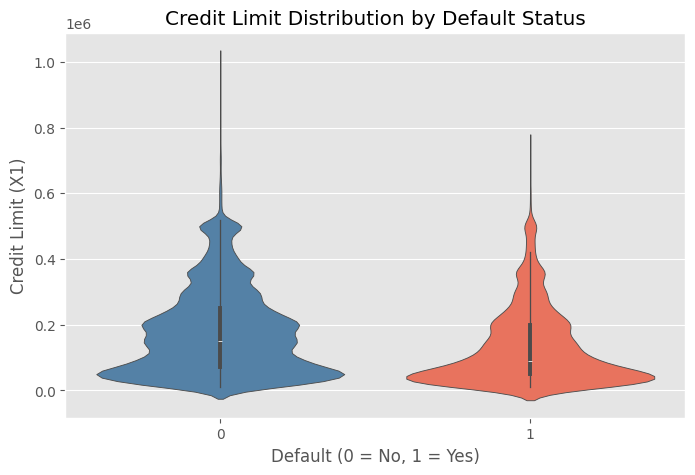

In [112]:
# Combine X and y temporarily for plotting
plot_df = X_final.copy()
plot_df['Y'] = y['Y'].values

plt.figure(figsize=(8,5))
sns.violinplot(x='Y', y='X1', data=plot_df ,
               hue='Y',
                palette=['steelblue', 'tomato'],
               inner='box' , legend=False)          # shows box plot inside violin

plt.title('Credit Limit Distribution by Default Status')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Credit Limit (X1)')
plt.show()

### 5.4 Default Rate by Age

Visualizing the relationship between age and default rate using a line plot.
This helps identify whether certain age groups are more likely to default
and reveals any trends in default behavior across different age groups.

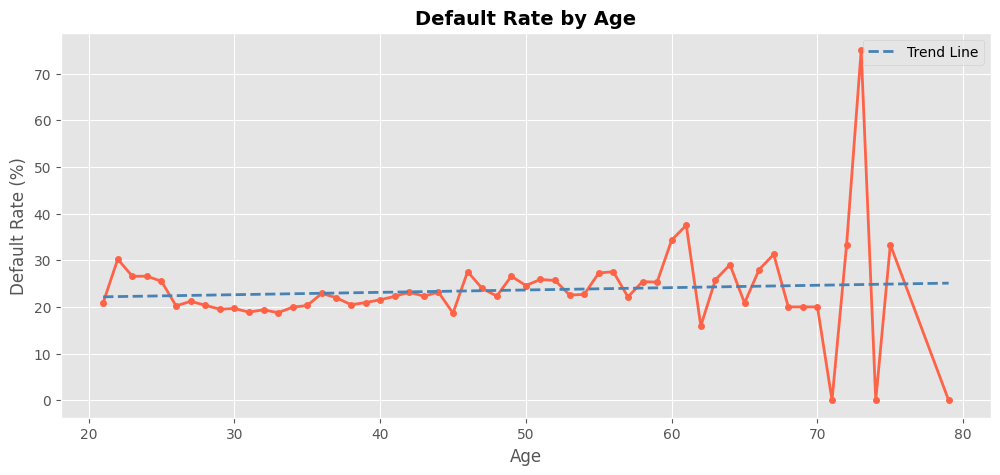

In [113]:
# Combine X and y temporarily for plotting
plot_df = X_final.copy()
plot_df['Y'] = y['Y'].values

# Calculate default rate per age
age_default = plot_df.groupby('X5')['Y'].mean().mul(100)

plt.figure(figsize=(12,5))
plt.plot(age_default.index, age_default.values, 
         color='tomato', 
         linewidth=2,
         marker='o',          # adds dot at each age point
         markersize=4)

# Add a trend line
z = np.polyfit(age_default.index, age_default.values, 1)
p = np.poly1d(z)
plt.plot(age_default.index, p(age_default.index), 
         color='steelblue', 
         linewidth=2,
         linestyle='--',      # dashed trend line
         label='Trend Line')

plt.title('Default Rate by Age', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Default Rate (%)')
plt.legend()
plt.show()

### 5.5 Correlation Heatmap

Visualizing the correlation between all features to identify relationships
and detect any redundant features that may affect model performance.

Dark Red   → strong positive correlation (move together)

Dark Blue  → strong negative correlation (move opposite)

White/Light → little or no correlation

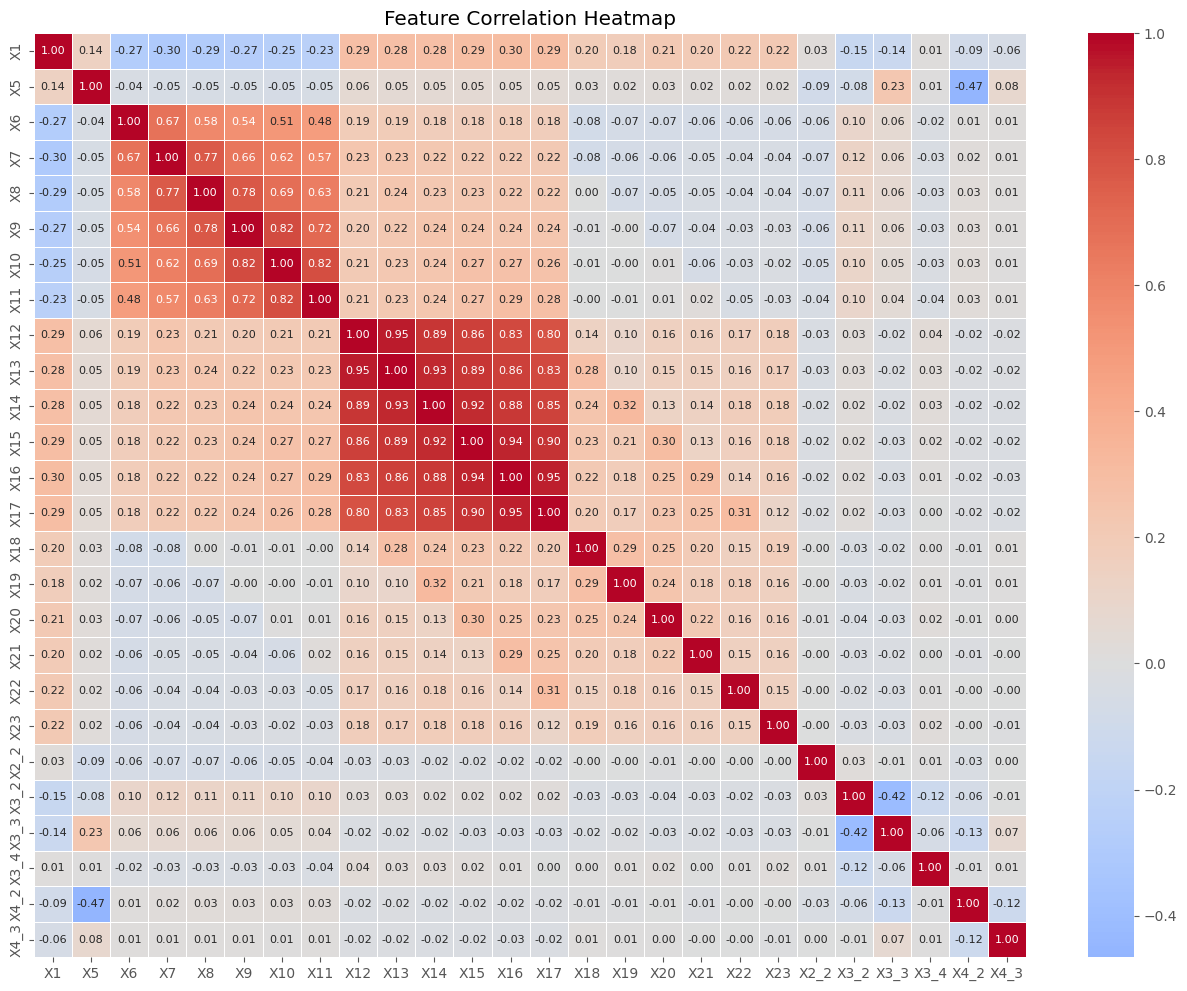

In [114]:
plt.figure(figsize=(16,12))
sns.heatmap(X_final.corr(), 
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt=".2f",        # format for annotation
            annot_kws={"size": 8},  # annotation font size         
            linewidths=0.5,
           )     

plt.title('Feature Correlation Heatmap')
plt.show()

## 6. Train/Test Split

The dataset is split into 80% training and 20% testing sets. Stratification is applied
to ensure both splits maintain the same 78/22 class ratio as the original dataset.
This prevents accidental worsening of the imbalance in either split.

In [115]:
##spliting
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True, 
    stratify=y
)

## 7. Feature Scaling

RobustScaler is applied only on the training set to avoid data leakage.
RobustScaler is used instead of StandardScaler because it is less sensitive
to outliers, using median and interquartile range instead of mean and standard deviation.
The same scaler is later applied to the test set using transform only.

In [116]:

##scaling to train data 
num_cols = ['X1','X5','X12','X13','X14','X15','X16','X17','X18','X19','X20','X21','X22','X23']
scaler=RobustScaler()

X_train_scaled = X_train.copy()
X_train_scaled[num_cols]=scaler.fit_transform(X_train[num_cols])
print (X_train.head())

           X1  X5  X6  X7  X8  X9  X10  X11     X12     X13     X14     X15  \
17300  150000  32   6   5   4   3    2    2   81341   79529   77757   75841   
29669  150000  41   3   2   2   0    0    2  111056  113467  110235  111376   
12602   30000  41   2   2   0   0    0   -1   25594   21485   22320   23933   
21950  230000  27  -1   2  -1  -1    0   -1    6155    5650    3004    4200   
6072   100000  26   0   0   0  -1    0    0   22320   15193   13516    1541   

          X16     X17   X18   X19   X20    X21   X22   X23  X2_2  X3_2  X3_3  \
17300   73678   77273     0     0     0      0  4874  1000     1     1     0   
29669  154802  152304  5700     0  4500  45500     0  5400     0     0     0   
12602   22742    2500     0  1300  5000    945  1850  1060     1     1     0   
21950    1400    4222   500  3004  4200      0  4222  4649     1     0     1   
6072     8805   11329  1227  1150  1600   8000  5000     0     1     1     0   

       X3_4  X4_2  X4_3  
17300     0     1 

## 8. Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) is applied only on the training set
to generate synthetic samples for the minority class (defaulters). This helps the model
learn patterns from both classes equally without seeing test data during resampling.

In [117]:
## SMOTE
smote_sampler=SMOTE(random_state=42)
X_train_res,y_train_res=smote_sampler.fit_resample(X_train_scaled,y_train)

print(y_train_res.value_counts(normalize=True)*100)

Y
0    50.0
1    50.0
Name: proportion, dtype: float64


## 9. Correlation Filtering

Features with more than 90% correlation with another feature are removed.
Highly correlated features are redundant and add noise without adding new information,
which can hurt model performance and interpretability.

In [118]:
#CORRELATION FILTERING
# We remove features with > 90% correlation to reduce redundancy and noise.
corr_matrix = X_train_res.corr().abs() 
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
X_train_no_corr = X_train_res.drop(columns=to_drop)


## 10. Feature Selection using SelectKBest

SelectKBest is applied to select the top 10 most statistically significant features
using ANOVA F-score. This reduces dimensionality, speeds up training, and helps
the model focus on the most predictive features only.

In [119]:
 #FEATURE SELECTION USING SELECTKBEST
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=10)
X_train_final = selector.fit_transform(X_train_no_corr, y_train_res) 

# Extract and print the names of the selected 10 features
mask = selector.get_support()
best_features = X_train_no_corr.columns[mask]
print(f"Final 10 unique and important features: {list(best_features)}")

Final 10 unique and important features: ['X1', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X18', 'X2_2', 'X4_2']


c:\Users\fatma\OneDrive\Documentos\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## 11. Test Data Preparation

The same scaling, correlation filtering, and feature selection transformations
applied to training data are now applied to the test set using transform only.
This ensures no information from the test set leaks into the preprocessing pipeline.

In [120]:
##TEST DATA PREPARATION#3
##scaling to test data 
X_test_scaled = X_test.copy()
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_test_no_corr = X_test_scaled.drop(columns=to_drop)
X_test_final = selector.transform(X_test_no_corr)

## 12. Modeling

### 12.1 Imports

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score

### 12.2 Cross Validation

5-fold cross validation is applied to verify model stability and ensure
results are not dependent on a single train/test split.

In [122]:
from sklearn.model_selection import cross_validate


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTreeClassifier': DecisionTreeClassifier(max_depth=5,random_state=42),
    'SVM': SVC(C=1.5 ,random_state=42, cache_size=700)
}


scoring_metrics=['accuracy','f1',]
results_list=[]
for name ,models in models.items() :

    cv_scores = cross_validate(models, X_train_final, y_train_res.values.ravel(),
                            cv=5, scoring=scoring_metrics)
    results_list.append({
        'Model': name,
        'Mean Accuracy': np.mean(cv_scores['test_accuracy']),
        'Std Accuracy': np.std(cv_scores['test_accuracy']),
        'Mean F1-Score': np.mean(cv_scores['test_f1']),
        'Std F1-Score': np.std(cv_scores['test_f1'])
    })                        

comparison_df = pd.DataFrame(results_list).sort_values(by='Mean F1-Score', ascending=False)

print("--- Model Comparison Results (Cross-Validation) ---")
display(comparison_df)

--- Model Comparison Results (Cross-Validation) ---


,Model,Mean Accuracy,Std Accuracy,Mean F1-Score,Std F1-Score
0,Logistic Regression,0.676181,0.009082,0.675077,0.011143
1,DecisionTreeClassifier,0.710672,0.005445,0.661317,0.007623
2,SVM,0.702873,0.003993,0.656058,0.006510


### 12.3.1 Logistic Regression

Logistic Regression is used as the baseline classifier for Phase 1.
It is interpretable, computationally efficient, and provides a clear
performance benchmark for comparison with more complex models in Phase 2.

In [123]:
## Modelling 1
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_final, y_train_res)

y_pred_log     = log_reg.predict(X_test_final)
y_test_flat = y_test.values.ravel()

print("\n--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test_flat, y_pred_log):.4f}")
print(f"F1-Score: {f1_score(y_test_flat, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_log))


--- Logistic Regression Performance ---
Accuracy: 0.6684
F1-Score: 0.4556

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.68      0.76      4665
           1       0.36      0.63      0.46      1324

    accuracy                           0.67      5989
   macro avg       0.61      0.65      0.61      5989
weighted avg       0.75      0.67      0.69      5989



c:\Users\fatma\OneDrive\Documentos\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### 12.3.2 Confusion Matrix and ROC Curve

The confusion matrix shows the breakdown of correct and incorrect predictions
for both classes, helping identify where the model fails.

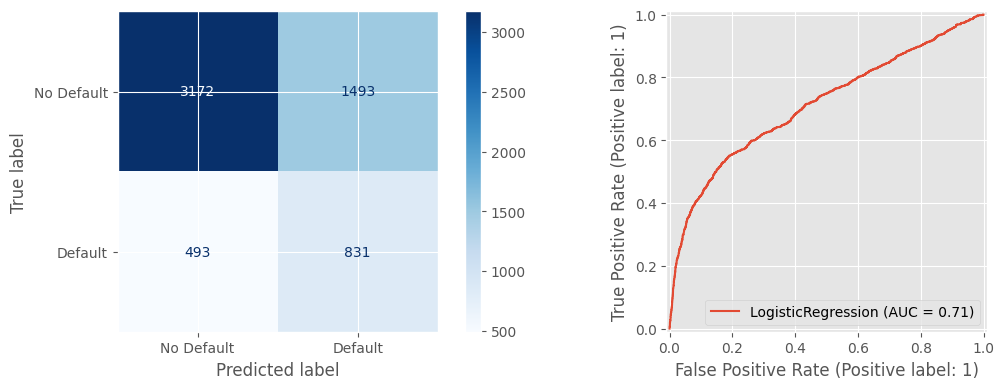

In [124]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test_flat, y_pred_log, 
                                        display_labels=['No Default','Default'], 
                                        cmap='Blues', ax=ax[0])
RocCurveDisplay.from_estimator(log_reg, X_test_final, y_test, ax=ax[1])
plt.tight_layout()
plt.show()

### 12.4.1 Decision_Tree



In [125]:
## Modelling 2
Decision_Tree = DecisionTreeClassifier(max_depth=5,random_state=42)
Decision_Tree.fit(X_train_final, y_train_res)

y_pred_dt    = Decision_Tree.predict(X_test_final)


print("\n--- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test_flat, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test_flat, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_dt))


--- Decision Tree Performance ---
Accuracy: 0.7806
F1-Score: 0.5183

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4665
           1       0.50      0.53      0.52      1324

    accuracy                           0.78      5989
   macro avg       0.68      0.69      0.69      5989
weighted avg       0.79      0.78      0.78      5989



### 12.4.2 Confusion Matrix and ROC Curve

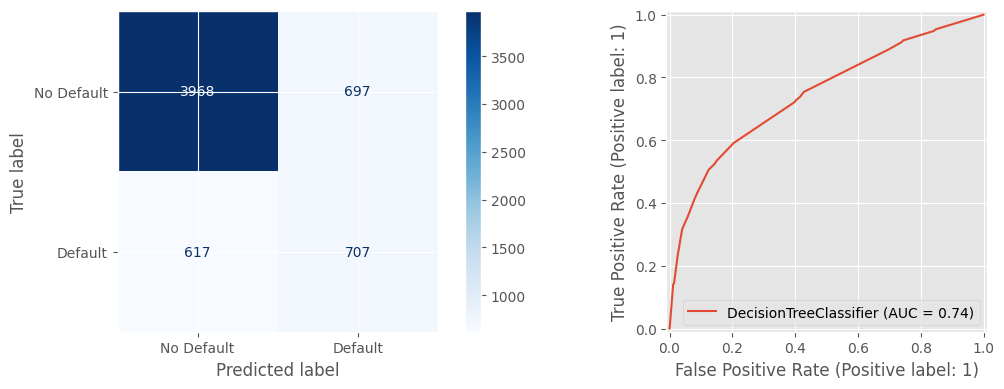

In [126]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test_flat, y_pred_dt, 
                                        display_labels=['No Default','Default'], 
                                        cmap='Blues', ax=ax[0])
RocCurveDisplay.from_estimator(Decision_Tree, X_test_final, y_test, ax=ax[1])
plt.tight_layout()
plt.show()

### 12.5.1 SVM

In [127]:
## Modelling 3
svm_model = SVC(C=1.5 ,random_state=42, cache_size=700)
svm_model.fit(X_train_final, y_train_res)

y_pred_svm    = svm_model.predict(X_test_final)


print("\n--- SVM Performance ---")
print(f"Accuracy: {accuracy_score(y_test_flat, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test_flat, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_svm))

c:\Users\fatma\OneDrive\Documentos\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



--- SVM Performance ---
Accuracy: 0.7751
F1-Score: 0.5239

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4665
           1       0.49      0.56      0.52      1324

    accuracy                           0.78      5989
   macro avg       0.68      0.70      0.69      5989
weighted avg       0.79      0.78      0.78      5989



### 12.5.2

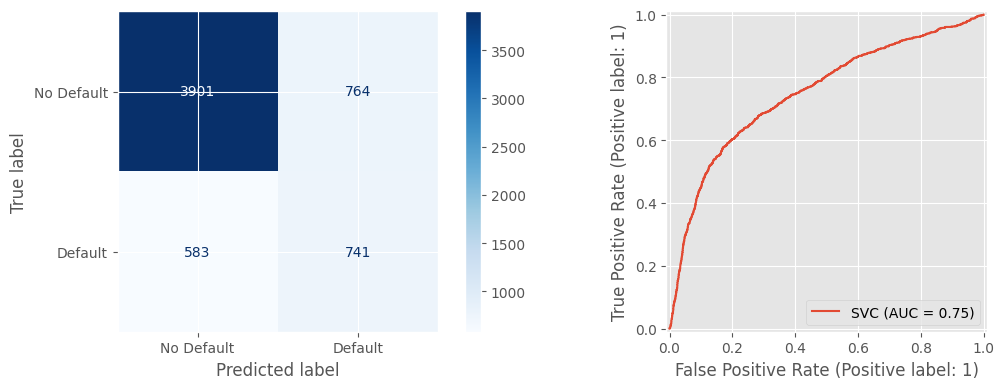

In [128]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test_flat, y_pred_svm, 
                                        display_labels=['No Default','Default'], 
                                        cmap='Blues', ax=ax[0])
RocCurveDisplay.from_estimator(svm_model, X_test_final, y_test, ax=ax[1])
plt.tight_layout()
plt.show()